# Medical Question Answering — Projet académique

Ce notebook implémente un système de **Medical Q&A** en comparant plusieurs stratégies :
- **Stratégie 1** : Zero-shot (Direct + Prompt Engineering)
- **Stratégie 2** : RAG (Retrieval Augmented Generation)
- **Stratégie 3** : Fine-tuning QLoRA

**Environnement** : Google Colab (GPU T4), PyTorch, Transformers, PEFT, TRL, Evaluate, LangChain.

# Partie proche du cours

---
## Étape 1 : Installation et préparation

On installe les dépendances, charge le dataset **medalpaca/medical_meadow_medical_flashcards**, l’analyse succinctement et crée un split **90 % train / 10 % test** (pas de split fourni par le dataset).

### 1.1 Installation des dépendances

Exécuter cette cellule en premier (idéalement avec **GPU T4** activé dans Colab : *Runtime > Change runtime type*).

In [1]:
# Installation des bibliothèques pour Colab (GPU T4)
!pip install -q torch transformers accelerate bitsandbytes
!pip install -q peft trl datasets
!pip install -q evaluate rouge_score sacrebleu
!pip install -q langchain langchain-community langchain-core
!pip install -q sentence-transformers
# FAISS : faiss-gpu sur Colab avec GPU, sinon faiss-cpu
!pip install -q faiss-cpu

print("Installation terminée.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.9/532.9 kB 11.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 1

In [2]:
# # Installation des bibliothèques pour Colab (GPU T4)
# !pip install -q "torch>=2.0" "transformers>=4.36" "accelerate>=0.25" "bitsandbytes>=0.41"
# !pip install -q "peft>=0.7" "trl>=0.7" "datasets>=2.14"
# !pip install -q "evaluate>=0.4" "rouge_score>=0.1" "sacrebleu"
# !pip install -q "langchain>=0.1" "langchain-community>=0.0.10" "langchain-core"
# !pip install -q "sentence-transformers>=2.2"
# # FAISS : faiss-gpu sur Colab avec GPU, sinon faiss-cpu
# !pip install -q faiss-cpu

# print("Installation terminée.")

### 1.2 Imports et configuration

In [1]:
import os
import gc
import torch
from datasets import load_dataset
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


### 1.3 Chargement et analyse du dataset

Le dataset fournit des paires **Question / Answer** (colonnes `input` et `output`). Il n’y a pas de split ; on utilisera `train_test_split` pour créer train (90 %) et test (10 %).

In [2]:
DATASET_NAME = "medalpaca/medical_meadow_medical_flashcards"

dataset = load_dataset(DATASET_NAME)
print("Clés:", dataset.keys())
print("Structure:", dataset)

# Le dataset a souvent une clé "train"
if "train" in dataset:
    full = dataset["train"]
else:
    full = dataset[list(dataset.keys())[0]]

print("\nColonnes:", full.column_names)
print("Nombre d'exemples:", len(full))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Clés: dict_keys(['train'])
Structure: DatasetDict({
    train: Dataset({
        features: ['input', 'output', 'instruction'],
        num_rows: 33955
    })
})

Colonnes: ['input', 'output', 'instruction']
Nombre d'exemples: 33955


### 1.4 Exemples et normalisation des colonnes

On s’assure d’avoir des champs `question` et `answer` (en mappant `input` → `question`, `output` → `answer` si nécessaire).

In [3]:
# Normalisation : input -> question, output -> answer (medalpaca)
data = full.rename_columns({"input": "question", "output": "answer"})
data = data.remove_columns([c for c in data.column_names if c not in ["question", "answer"]])

# 2–3 exemples
for i in range(min(3, len(data))):
    r = data[i]
    print(f"--- Exemple {i+1} ---\nQuestion: {(r['question'][:180] + '...') if len(r['question']) > 180 else r['question']}\nAnswer: {(r['answer'][:180] + '...') if len(r['answer']) > 180 else r['answer']}\n")

--- Exemple 1 ---
Question: What is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels?
Answer: Very low Mg2+ levels correspond to low PTH levels which in turn results in low Ca2+ levels.

--- Exemple 2 ---
Question: What leads to genitourinary syndrome of menopause (atrophic vaginitis)?
Answer: Low estradiol production leads to genitourinary syndrome of menopause (atrophic vaginitis).

--- Exemple 3 ---
Question: What does low REM sleep latency and experiencing hallucinations/sleep paralysis suggest?
Answer: Low REM sleep latency and experiencing hallucinations/sleep paralysis suggests narcolepsy.



### 1.5 Split 90 % train / 10 % test

Split aléatoire avec `train_test_split` (seed pour reproductibilité). Le **test** servira à l’évaluation des stratégies.

In [4]:
# 90 % train, 10 % test (seed=42)
splits = data.train_test_split(test_size=0.10, seed=42)
train_data = splits["train"]
test_data = splits["test"]
print(f"Train: {len(train_data)} | Test: {len(test_data)}")

Train: 30559 | Test: 3396


---
## Étape 2 : Stratégie 1 — Zero-shot et Prompt Engineering

On charge un **modèle léger en 4-bit** (TinyLlama ou Zephyr) et on définit `generate_answer(question, strategy="direct"|"prompt_engineering")` :
- **Direct** : seule la question est envoyée au modèle.
- **Prompt Engineering** : un *system prompt* du type *"You are a medical expert. Answer concisely."* est ajouté.

In [5]:
# Libérer la mémoire GPU avant de charger un nouveau modèle
def _clear_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Modèle léger compatible Colab T4 (Qwen 7B) en 4-bit
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, quantization_config=bnb, device_map="auto")
model.eval()
print("Modèle chargé (4-bit).")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modèle chargé (4-bit).


In [6]:
few_shot_examples = (
    "Here are examples of the expected answer style:\n\n"
    "Question: What is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels?\n"
    "Answer: Very low Mg2+ levels correspond to low PTH levels which in turn results in low Ca2+ levels.\n\n"
    "Question: What leads to genitourinary syndrome of menopause (atrophic vaginitis)?\n"
    "Answer: Low estradiol production leads to genitourinary syndrome of menopause (atrophic vaginitis).\n\n"
    "Question: What does low REM sleep latency and experiencing hallucinations/sleep paralysis suggest?\n"
    "Answer: Low REM sleep latency and experiencing hallucinations/sleep paralysis suggests narcolepsy.\n\n"
)

In [7]:
def generate_answer(question, strategy="direct", model=model, tokenizer=tokenizer, context=None, max_new_tokens=80):
    """
    Version corrigée qui gère mieux les tenseurs pour éviter l'erreur de shape.
    """
    # 1. Construction du message selon la stratégie

    if strategy == "direct":
        messages = [{"role": "user", "content": question}]

    elif strategy == "prompt_engineering":
        content = "You are a medical expert. Answer the following question concisely in one or two sentences.\n\n" + question
        messages = [{"role": "user", "content": content}]

    elif strategy == "few_shot_prompting":
        content = (
            "You are a medical expert. Answer the question directly in a single sentence. "
            "Do not start with 'The answer is'.\n\n"
            + few_shot_examples +
            f"Question: {question}\nAnswer:"
        )
        messages = [{"role": "user", "content": content}]

    elif strategy == "rag" and context:
        user = f"Use the following context to answer.\n\nContext:\n{context}\n\nQuestion: {question}"
        messages = [{"role": "user", "content": user}]

    else:
        messages = [{"role": "user", "content": question}]

    # 2. Tokenization sécurisée (On ne demande PAS de dictionnaire, juste les IDs)
    input_ids = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"  # Force le retour d'un tenseur PyTorch
    ).to(model.device)

    # 3. Génération
    with torch.no_grad():
        out = model.generate(
            input_ids, # On passe directement le tenseur
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    # 4. Décodage (On coupe l'input pour ne garder que la réponse)
    # input_ids.shape[-1] nous donne la longueur exacte du prompt
    decoded_text = tokenizer.decode(out[0][input_ids.shape[-1]:], skip_special_tokens=True).strip()

    return decoded_text

---
## Étape 3 : Stratégie 2 — RAG (Retrieval Augmented Generation)

Pipeline RAG avec **LangChain** : embeddings **SentenceTransformer**, base vectorielle **FAISS**.
On indexe une **petite partie du train** comme base de connaissance (ou Wikipedia si on le souhaite).
La génération récupère le contexte pertinent puis appelle le LLM.

In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.documents import Document

# Embeddings : SentenceTransformer via HuggingFace
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Sous-ensemble du train comme base de connaissance (ex. 800 ex.)
n_rag = min(800, len(train_data))
docs = [
    Document(page_content=train_data[i]["question"], metadata={"answer": train_data[i]["answer"]})
    for i in range(n_rag)
]
vectorstore = FAISS.from_documents(docs, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
print("Index FAISS construit, k=3.")

In [9]:
def get_rag_context(question, retriever=retriever):
    hits = retriever.invoke(question)

    parts = [f"Q: {d.page_content} A: {d.metadata.get('answer', '')}" for d in hits]
    return "\n\n".join(parts)

def generate_answer_rag(question, model=model, tokenizer=tokenizer):
    context = get_rag_context(question)
    return generate_answer(question, strategy="rag", context=context, model=model, tokenizer=tokenizer)

---
## Étape 4 : Stratégie 3 — Fine-tuning QLoRA

Fine-tuning avec **PEFT (LoRA)** et **SFTTrainer (TRL)** en 4-bit (QLoRA).  
Réglage volontairement **léger** : 1 epoch, `max_steps` limité (~50) pour rester sous ~15 min sur Colab.  
Sauvegarde de l’**adaptateur LoRA** à la fin.

In [10]:
# Libérer le modèle d'inférence pour faire de la place au fine-tuning
del model
_clear_cuda()

from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Recharger le modèle en 4-bit pour l'entraînement
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
model_ft = AutoModelForCausalLM.from_pretrained(MODEL_NAME, quantization_config=bnb, device_map="auto")
model_ft = prepare_model_for_kbit_training(model_ft)

peft_config = LoraConfig(r=8, lora_alpha=16, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")

def formatting_prompts_func(ex):
    # Format type ChatML (compatible TinyLlama, SmolLM, etc.)
    return f"<|im_start|>user\n{ex['question']}<|im_end|>\n<|im_start|>assistant\n{ex['answer']}<|im_end|>"

# Sous-ensemble d'entraînement pour aller vite (~100 ex)
n_train_ft = min(100, len(train_data))
train_ft = train_data.select(range(n_train_ft))

sft_config = SFTConfig(
    output_dir="./lora_medical_qa",
    num_train_epochs=1,
    max_steps=50,
    max_length=256,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    fp16=False,
    bf16=torch.cuda.is_available(),
    logging_steps=10,
    save_steps=50,
    save_total_limit=1,
)

trainer = SFTTrainer(
    model=model_ft,
    args=sft_config,
    train_dataset=train_ft,
    formatting_func=formatting_prompts_func,
    peft_config=peft_config,
)
trainer.train()
trainer.save_model("./lora_medical_qa")
print("Adaptateur LoRA sauvegardé dans ./lora_medical_qa")

Applying formatting function to train dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Step,Training Loss
10,1.889800
20,1.445600
30,1.468200
40,1.414000
50,1.410600


wandb: WARNING URL not available in offline run


Adaptateur LoRA sauvegardé dans ./lora_medical_qa


In [11]:
import shutil
from google.colab import files

# 1. On compresse le dossier en un fichier .zip
shutil.make_archive('mon_modele_lora', 'zip', './lora_medical_qa')

# 2. On déclenche le téléchargement dans ton navigateur
files.download('mon_modele_lora.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Étape 5 : Évaluation et comparaison

On évalue sur un **sous-ensemble de 20 exemples du test**.  
- **ROUGE** : similarité syntaxique entre prédiction et réponse de référence.  
- **LLM-as-a-judge** : le modèle note de 1 à 5 la pertinence de la réponse par rapport à la référence.  
Tableau final : scores moyens pour **Direct**, **Prompt**, **RAG**, **Fine-tuned**.

In [12]:
import evaluate

# Sous-ensemble de test (20 ex.) pour évaluation rapide
N_EVAL = 20
eval_data = test_data.select(range(min(N_EVAL, len(test_data))))
questions = [eval_data[i]["question"] for i in range(len(eval_data))]
gold = [eval_data[i]["answer"] for i in range(len(eval_data))]

def compute_rouge(pred, ref):
    r = evaluate.load("rouge")
    res = r.compute(predictions=[pred], references=[ref])
    def _v(k):
        x = res.get(k)
        if x is None: return 0.0
        return float(x[0]) if isinstance(x, list) else float(x)
    return {"rouge1": _v("rouge1"), "rouge2": _v("rouge2"), "rougeL": _v("rougeL")}

def compute_bleu(pred, ref):
    # BLEU : references = [[ref]] (liste de refs par prédiction)
    b = evaluate.load("bleu")
    res = b.compute(predictions=[pred], references=[[ref]])
    x = res.get("bleu")
    if x is None: return 0.0
    return float(x[0]) if isinstance(x, list) else float(x)

def llm_as_judge(question, gold_answer, pred_answer, model, tokenizer, max_new_tokens=20):
    """Note de 1 à 5 : pertinence de pred par rapport à gold."""
    prompt = f"On 1-5, rate how relevant this answer is to the reference (1=not relevant, 5=very relevant). Only output the number.\nRef: {gold_answer[:200]}\nPred: {pred_answer[:200]}\nScore:"
    messages = [{"role": "user", "content": prompt}]

    # --- CORRECTION ICI : On récupère directement le Tenseur (plus robuste) ---
    input_ids = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(model.device)

    # Gestion du pad_token si manquant
    pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id

    with torch.no_grad():
        # On passe input_ids directement, sans dictionnaire "**inp"
        out = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=pad_token_id
        )

    # Décodage : on ignore la partie prompt (input_ids.shape[-1]) pour ne garder que la réponse
    text = tokenizer.decode(out[0][input_ids.shape[-1]:], skip_special_tokens=True).strip()

    for c in text:
        if c.isdigit():
            return min(5, max(1, int(c)))
    return 3

print("Fonctions d'évaluation (ROUGE & LLM-as-Judge) chargées avec succès.")

Fonctions d'évaluation (ROUGE & LLM-as-Judge) chargées avec succès.


In [13]:
# Libérer la mémoire et recharger le modèle de base pour Direct, Prompt, RAG
try: del model_ft, trainer
except NameError: pass
_clear_cuda()

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, quantization_config=bnb, device_map="auto")
model.eval()

results = { "Direct":             {"rouge1": [], "rouge2": [], "rougeL": [], "bleu": [], "judge": []},
            "Prompt":             {"rouge1": [], "rouge2": [], "rougeL": [], "bleu": [], "judge": []},
            "FewShotPrompt":      {"rouge1": [], "rouge2": [], "rougeL": [], "bleu": [], "judge": []},
            "RAG":                {"rouge1": [], "rouge2": [], "rougeL": [], "bleu": [], "judge": []} }

for i in range(len(questions)):
    q, g = questions[i], gold[i]
    for strat, key in [("direct", "Direct"), ("prompt_engineering", "Prompt"), ("few_shot_prompting", "FewShotPrompt")]:
        pred = generate_answer(q, strategy=strat, model=model, tokenizer=tokenizer)
        r = compute_rouge(pred, g)
        results[key]["rouge1"].append(r["rouge1"] or 0)
        results[key]["rouge2"].append(r["rouge2"] or 0)
        results[key]["rougeL"].append(r["rougeL"] or 0)
        results[key]["bleu"].append(compute_bleu(pred, g))
        results[key]["judge"].append(llm_as_judge(q, g, pred, model, tokenizer))
        print(key + " évalué")
    pred_rag = generate_answer_rag(q, model=model, tokenizer=tokenizer)
    r = compute_rouge(pred_rag, g)
    results["RAG"]["rouge1"].append(r["rouge1"] or 0)
    results["RAG"]["rouge2"].append(r["rouge2"] or 0)
    results["RAG"]["rougeL"].append(r["rougeL"] or 0)
    results["RAG"]["bleu"].append(compute_bleu(pred, g))
    results["RAG"]["judge"].append(llm_as_judge(q, g, pred_rag, model, tokenizer))

print("Direct, Prompt, Few shot prompting, RAG évalués.")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Direct, Prompt, Few shot prompting, RAG évalués.


In [14]:
# Évaluation Fine-tuned : recharger base + adaptateur LoRA
try: del model
except NameError: pass
_clear_cuda()

from peft import PeftModel

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, quantization_config=bnb, device_map="auto")
model = PeftModel.from_pretrained(model, "./lora_medical_qa")
model.eval()

results["Fine-tuned"] = {"rouge1": [], "rouge2": [], "rougeL": [], "bleu": [], "judge": []}
for i in range(len(questions)):
    q, g = questions[i], gold[i]
    pred = generate_answer(q, strategy="prompt_engineering", model=model, tokenizer=tokenizer)
    r = compute_rouge(pred, g)
    results["Fine-tuned"]["rouge1"].append(r["rouge1"] or 0)
    results["Fine-tuned"]["rouge2"].append(r["rouge2"] or 0)
    results["Fine-tuned"]["rougeL"].append(r["rougeL"] or 0)
    results["Fine-tuned"]["bleu"].append(compute_bleu(pred, g))
    results["Fine-tuned"]["judge"].append(llm_as_judge(q, g, pred, model, tokenizer))

print("Fine-tuned évalué.")

Fine-tuned évalué.


In [15]:
# Tableau comparatif : moyennes par stratégie
rows = []
for name in ["Direct", "Prompt", "FewShotPrompt", "RAG", "Fine-tuned"]:
    r = results[name]
    rows.append({
        "Stratégie": name,
        "ROUGE-1": pd.Series(r["rouge1"]).mean(),
        "ROUGE-2": pd.Series(r["rouge2"]).mean(),
        "ROUGE-L": pd.Series(r["rougeL"]).mean(),
        "BLEU": pd.Series(r["bleu"]).mean(),
        "LLM-judge (1-5)": pd.Series(r["judge"]).mean(),
    })
df = pd.DataFrame(rows)
display(df)

,Stratégie,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,LLM-judge (1-5)
0,Direct,0.258366,0.110167,0.194915,0.038864,3.20
1,Prompt,0.360889,0.216206,0.314862,0.117999,3.15
2,FewShotPrompt,0.380964,0.224743,0.334485,0.082033,3.25
3,RAG,0.279344,0.166247,0.223822,0.082033,3.60
4,Fine-tuned,0.379736,0.240828,0.336182,0.130225,3.45


### Interprétation

- **ROUGE** mesure le chevauchement lexical (n-grammes) entre la prédiction et la référence ; des scores plus élevés indiquent une similarité de surface plus forte.
- **BLEU** mesure aussi le recouvrement en n-grammes (géométrique des précisions 1–4) ; il pénalise les prédictions trop courtes (brevity penalty).
- **LLM-as-a-judge** donne une note de pertinence sémantique (1–5) ; il est utile pour comparer des formulations différentes qui restent correctes.
- Le **fine-tuning** et le **RAG** ont souvent un avantage sur le zero-shot pour des questions médicales spécialisées, sous réserve de suffisamment de données (RAG) ou d’un entraînement adapté (QLoRA).

In [16]:
# Question | Réponse générée | Vraie réponse — pour tous les modèles/stratégies (répété plusieurs fois)

N_EX = 5  # nombre d'exemples à afficher
ex_sub = test_data.select(range(min(N_EX, len(test_data))))
q_list = [ex_sub[i]["question"] for i in range(len(ex_sub))]
g_list = [ex_sub[i]["answer"] for i in range(len(ex_sub))]

strategies = [
    ("Direct", lambda q: generate_answer(q, strategy="direct", model=model, tokenizer=tokenizer)),
    ("Prompt", lambda q: generate_answer(q, strategy="prompt_engineering", model=model, tokenizer=tokenizer)),
    ("Few-shot", lambda q: generate_answer(q, strategy="few_shot_prompting", model=model, tokenizer=tokenizer)),
    ("RAG", lambda q: generate_answer_rag(q, model=model, tokenizer=tokenizer)),
    ("Fine-tuned", lambda q: generate_answer(q, strategy="prompt_engineering", model=model, tokenizer=tokenizer)),
]

for i in range(len(q_list)):
    print("=" * 70)
    print(f"Exemple {i+1} / {len(q_list)}")
    print("=" * 70)
    print("Question:", q_list[i])
    print()
    for name, gen_fn in strategies:
        pred = gen_fn(q_list[i])
        print(f"  • {name}: {pred}")
    print(f"  • Référence (gold): {g_list[i]}")
    print()

Exemple 1 / 5
Question: What type of injury to the arm/elbow most often leads to supracondylar fractures?

  • Direct: Supracondylar fractures of the elbow are most commonly caused by direct trauma or falls from heights. The force of impact can cause the distal humerus to snap back into the proximal end of the ulna, resulting in a fracture at the upper part of the ulnar condyle.

This type of injury is more common among individuals who engage in sports that involve sudden movements and impacts,
  • Prompt: Motor vehicle accidents.
  • Few-shot: Supracondylar fractures of the elbow are most commonly caused by direct trauma to the area.
  • RAG: Supracondylar fractures of the elbow are most commonly caused by direct impact from an external source, such as a fall or a car accident. The term "supracondylar" refers to the location of the fracture, which involves the humerus (the upper arm bone) and the bony protrusion at the end of the forearm called the olecranon. The olecranon
  • Fine-tu

# Recherche RAG-orientée

In [18]:
from sentence_transformers import SentenceTransformer
import torch

# Chargement du modèle d'embedding léger
print("Chargement du modèle d'embedding (MiniLM)...")
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# Envoyer sur le GPU pour que ça aille vite
device = "cuda" if torch.cuda.is_available() else "cpu"
embedder.to(device)

print("✅ Embedder prêt.")

Chargement du modèle d'embedding (MiniLM)...
✅ Embedder prêt.


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
import numpy as np
import pandas as pd
from tqdm import tqdm

# --- PARAMÈTRES DU GRID SEARCH ---
# On explore une large gamme pour bien voir les tendances
N_values = [100, 500, 1000, 5000, 10000, 20000, 30000] # Nb données embeddées
k_values = [1, 3, 5, 10, 15]                           # Nb voisins

# Paramètres d'évaluation
n_eval = 50  # Nombre de questions de test (50 est un bon compromis vitesse/fiabilité)

# 1. PRÉPARATION (Optimisation majeure)
print("Pré-calcul des embeddings du Train Set (30k)...")
full_corpus = [f"Q: {ex['question']} \nA: {ex['answer']}" for ex in train_data]
# On embedde TOUT une seule fois (C'est l'étape la plus longue, ~2 min)
full_embeddings = embedder.encode(full_corpus, convert_to_tensor=False, show_progress_bar=True)
full_embeddings = np.array(full_embeddings).astype(np.float32)

# Préparation du Test Set
# On prend 50, ou tout le dataset si il y en a moins de 50
real_n_eval = min(n_eval, len(questions))
eval_indices = np.random.choice(len(questions), real_n_eval, replace=False)
eval_qs = [questions[i] for i in eval_indices]
eval_gs = [gold[i] for i in eval_indices]
eval_qs_emb = embedder.encode(eval_qs, convert_to_tensor=False)
eval_qs_emb = np.array(eval_qs_emb).astype(np.float32)

# Stockage des résultats : Une liste de dictionnaires est plus facile à transformer en DataFrame
results_list = []

print(f"Lancement du Grid Search ({len(N_values)} tailles x {len(k_values)} k)...")

# 2. DOUBLE BOUCLE (GRID SEARCH)
# On boucle d'abord sur N (le plus coûteux car il faut reconstruire l'index)
for N in N_values:
    if N > len(full_embeddings): continue

    # A. Construction de l'index FAISS pour cette taille N
    # On prend les N premiers (ou random)
    indices_kb = np.random.choice(len(full_embeddings), N, replace=False)

    current_index = faiss.IndexFlatL2(full_embeddings.shape[1])
    current_index.add(full_embeddings[indices_kb])

    # On prépare la recherche pour le plus grand k nécessaire (optimisation)
    max_k = max(k_values)
    D_all, I_all = current_index.search(eval_qs_emb, max_k)

    # B. Boucle sur k (très rapide car la recherche est déjà faite)
    for k in k_values:
        scores_rouge = []

        # CORRECTION ICI : On boucle sur la taille réelle (len(eval_qs)) et pas n_eval (50)
        for q_idx in range(len(eval_qs)):

            # Récupération des k voisins depuis le résultat de la recherche max_k
            neighbor_indices_local = I_all[q_idx][:k]

            # Il faut remonter aux indices réels dans le full_corpus
            real_indices = indices_kb[neighbor_indices_local]

            # Reconstruction du contexte
            parts = [full_corpus[idx] for idx in real_indices]
            context = "\n\n".join(parts)

            # Génération
            pred = generate_answer(eval_qs[q_idx], strategy="rag", context=context, model=model, tokenizer=tokenizer)

            # Scoring (ROUGE-L)
            r = evaluate.load("rouge").compute(predictions=[pred], references=[eval_gs[q_idx]])
            scores_rouge.append(r['rougeL'])

        avg_score = np.mean(scores_rouge)
        results_list.append({"N": N, "k": k, "score": avg_score})
        print(f"N={N}, k={k} -> Score: {avg_score:.4f}")

# Conversion en DataFrame pour faciliter les plots
df_res = pd.DataFrame(results_list)

# 3. GÉNÉRATION DES GRAPHIQUES

# Graphe 1 : La Heatmap (Vue globale)
plt.figure(figsize=(8, 6))
pivot_table = df_res.pivot(index="N", columns="k", values="score")
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
plt.title("Heatmap Performance RAG (ROUGE-L)")
plt.ylabel("Taille Base (N)")
plt.xlabel("Nombre Voisins (k)")
plt.show()

# Recherche du meilleur couple (k_opt, N_opt)
best_row = df_res.loc[df_res['score'].idxmax()]
best_N, best_k = int(best_row['N']), int(best_row['k'])
print(f"Meilleure configuration trouvée : N={best_N}, k={best_k} (Score: {best_row['score']:.4f})")

# Graphe 2 : Étude sur N (à k = best_k)
plt.figure(figsize=(8, 4))
df_N = df_res[df_res['k'] == best_k]
plt.plot(df_N['N'], df_N['score'], marker='o', linestyle='-', color='b')
plt.title(f"Impact de la taille de la base (à k={best_k} fixé)")
plt.xlabel("Nombre de documents (N)")
plt.ylabel("Score ROUGE-L")
plt.grid(True)
plt.show()

# Graphe 3 : Étude sur k (à N = best_N, ou N=30000 si best_N est max)
# Souvent on préfère fixer N au max pour voir le comportement asymptotique de k
target_N = 30000 if 30000 in N_values else best_N
plt.figure(figsize=(8, 4))
df_k = df_res[df_res['N'] == target_N]
plt.plot(df_k['k'], df_k['score'], marker='s', linestyle='-', color='r')
plt.title(f"Impact du nombre de voisins (à N={target_N} fixé)")
plt.xlabel("Nombre de voisins (k)")
plt.ylabel("Score ROUGE-L")
plt.grid(True)
plt.show()

Pré-calcul des embeddings du Train Set (30k)...


Batches:   0%|          | 0/955 [00:00<?, ?it/s]

Lancement du Grid Search (7 tailles x 5 k)...
N=100, k=1 -> Score: 0.2719
N=100, k=3 -> Score: 0.2369
N=100, k=5 -> Score: 0.2704
N=100, k=10 -> Score: 0.2730


KeyboardInterrupt: 


--- Lancement de l'étude : N=1000, k=[1, 2, 3, 5, 8, 10, 15], 5 runs ---

Run 1/5 : Tirage aléatoire de 1000 documents...



Run 2/5 : Tirage aléatoire de 1000 documents...



Run 3/5 : Tirage aléatoire de 1000 documents...



Run 4/5 : Tirage aléatoire de 1000 documents...



Run 5/5 : Tirage aléatoire de 1000 documents...


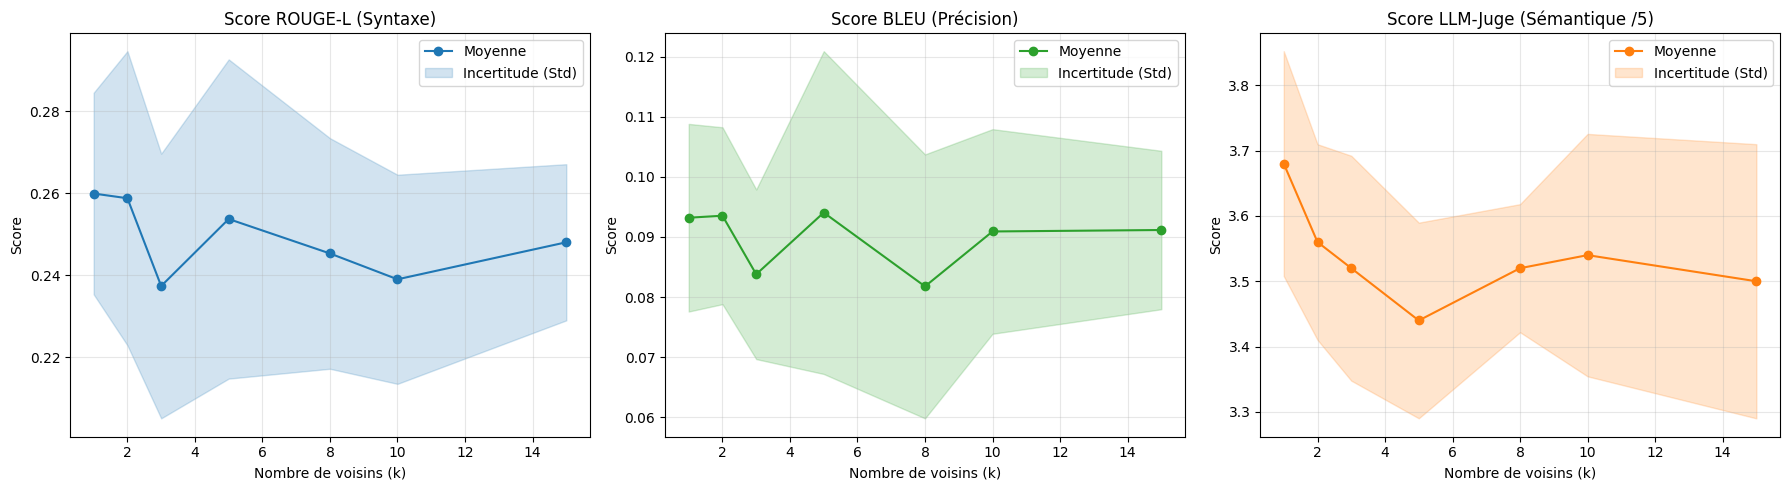

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import evaluate
import faiss
from tqdm import tqdm

# --- PARAMÈTRES ---
N_fixed = 1000          # On fixe la base de connaissance à 1000 documents
k_values = [1, 2, 3, 5, 8, 10, 15] # On fait varier k
n_runs = 5              # Nombre de répétitions pour calculer l'incertitude
n_eval_questions = 10   # Nombre de questions de test (rapide)

# Chargement des métriques
rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("bleu")

# Structure de stockage : {k: {'rouge': [], 'bleu': [], 'judge': []}}
results = {k: {'rouge': [], 'bleu': [], 'judge': []} for k in k_values}

# --- PRÉPARATION ---

# 1. Vérification des embeddings (On ne recalcule pas si déjà en mémoire)
if 'full_embeddings' not in locals() or 'full_corpus' not in locals():
    print("Calcul des embeddings du train set (30k)...")
    full_corpus = [f"Q: {ex['question']} \nA: {ex['answer']}" for ex in train_data]
    full_embeddings = embedder.encode(full_corpus, convert_to_tensor=False, show_progress_bar=True)
    full_embeddings = np.array(full_embeddings).astype(np.float32)

# 2. Choix d'un Test Set FIXE (pour que les variations viennent du RAG, pas du test)
real_n_eval = min(n_eval_questions, len(questions))
test_indices = np.random.choice(len(questions), real_n_eval, replace=False)
eval_qs = [questions[i] for i in test_indices]
eval_gs = [gold[i] for i in test_indices]

# On pré-calcule les embeddings des questions de test
eval_qs_emb = embedder.encode(eval_qs, convert_to_tensor=False)
eval_qs_emb = np.array(eval_qs_emb).astype(np.float32)

print(f"\n--- Lancement de l'étude : N={N_fixed}, k={k_values}, {n_runs} runs ---")

# --- BOUCLE PRINCIPALE (RUNS) ---
for run in range(n_runs):
    print(f"\nRun {run+1}/{n_runs} : Tirage aléatoire de {N_fixed} documents...")

    # A. On tire 1000 documents au hasard dans le train set
    indices_kb = np.random.choice(len(full_embeddings), N_fixed, replace=False)

    # B. Construction Index FAISS Éphémère
    index = faiss.IndexFlatL2(full_embeddings.shape[1])
    index.add(full_embeddings[indices_kb])

    # C. Recherche Optimisée (On cherche le max de k une seule fois)
    max_k = max(k_values)
    D_all, I_all = index.search(eval_qs_emb, max_k)

    # D. Boucle sur les valeurs de k
    for k in tqdm(k_values, desc="Test des k", leave=False):
        preds_k = []
        scores_judge_k = []

        for q_idx in range(len(eval_qs)):
            # Récupération des indices locaux (0 à N-1)
            local_neighbors = I_all[q_idx][:k]
            # Conversion en indices réels (0 à 30000)
            real_indices = indices_kb[local_neighbors]

            # Reconstruction contexte
            context = "\n\n".join([full_corpus[idx] for idx in real_indices])

            # Génération
            pred = generate_answer(eval_qs[q_idx], strategy="rag", context=context, model=model, tokenizer=tokenizer)
            preds_k.append(pred)

            # Score Juge (LLM-as-a-Judge)
            try:
                # Utilise ta fonction llm_as_judge définie plus haut
                s_judge = llm_as_judge(eval_qs[q_idx], eval_gs[q_idx], pred, model, tokenizer)
                scores_judge_k.append(s_judge)
            except Exception as e:
                scores_judge_k.append(0) # Fallback en cas d'erreur

        # Calcul des moyennes pour ce run
        r = rouge_metric.compute(predictions=preds_k, references=eval_gs)
        b = bleu_metric.compute(predictions=preds_k, references=eval_gs)

        # Stockage
        results[k]['rouge'].append(r['rougeL'])
        results[k]['bleu'].append(b['bleu'])
        results[k]['judge'].append(np.mean(scores_judge_k))

# --- AFFICHAGE DES GRAPHIQUES ---
metrics_name = ['rouge', 'bleu', 'judge']
titles = ['Score ROUGE-L (Syntaxe)', 'Score BLEU (Précision)', 'Score LLM-Juge (Sémantique /5)']
colors = ['tab:blue', 'tab:green', 'tab:orange']

plt.figure(figsize=(18, 5))

for i, metric in enumerate(metrics_name):
    plt.subplot(1, 3, i+1)

    means = []
    stds = []

    # Calcul Moyenne et Écart-Type
    for k in k_values:
        data = results[k][metric]
        means.append(np.mean(data))
        stds.append(np.std(data))

    means = np.array(means)
    stds = np.array(stds)

    # Plot Courbe + Zone d'incertitude
    plt.plot(k_values, means, marker='o', color=colors[i], label='Moyenne')
    plt.fill_between(k_values, means - stds, means + stds, color=colors[i], alpha=0.2, label='Incertitude (Std)')

    plt.title(titles[i])
    plt.xlabel("Nombre de voisins (k)")
    plt.ylabel("Score")
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()